# 🚀 미니프로젝트 2 — 회귀: 서울 자전거 대여 수요 예측 💡

날씨와 시간 정보로 **미래 시점의** 서울 공공자전거 대여량을 예측합니다. 시계열 성격이 있는 자료이므로 과거→미래 순서를 지키고, train으로 학습하고 validation으로 설정을 고른 뒤 test는 마지막 1회만 엽니다.

| 구분 | 내용 | 제출물 |
|---|---|---|
| **1차 (필수)** | 날짜순 train/validation/test · 표준화 · MAE 해석 · validation 실험 3개 이상 | 이 노트북 |
| **2차 (필수)** | 회귀 앱 핵심 TODO 4개 완성 | 독립 앱 동작 |
| **3차 (필수)** | 분류·회귀 통합 showcase + 모델 설명 | showcase URL |
| 🏆 **리더보드** | validation으로 확정한 모델의 최종 test MAE | 제출 양식 1행 |
| 🏅 **도전** | 시간 특성 추가가 미래 validation에서도 통하는지 검증 | 이 노트북 |

> 무작위 셔플은 미래의 계절·날씨 정보를 과거 훈련에 섞을 수 있습니다. 이번 과제의 질문이 “앞으로의 수요”이므로 날짜순 분할이 평가 계약입니다.

**평가 기준** — TODO 완성 · MAE 해석 · validation 실험 3개 이상 · 그래프 2종 · 최종 test 1회 · 앱 TODO 4개 · 통합 showcase URL


## 🔑 이 과제의 계약 6줄

1. 입력: `(N, 9)` float32, **train 통계로 표준화**
2. 분할: 날짜순 **train 70% / validation 15% / test 15%**
3. 모델 출력: `(N, 1)` 연속값
4. 정답: `(N, 1)` float32, 단위는 대
5. 손실: `nn.MSELoss()`, 평가: MAE
6. 모델 선택은 validation, 최종 보고만 test

| 함수/클래스 | 역할 |
|---|---|
| `pd.to_datetime()` + `sort_values()` | 날짜·시간 순서를 명시적으로 정렬 |
| `nn.MSELoss()` | 큰 오차를 더 강하게 벌주는 학습 손실 |
| `np.abs(pred-y).mean()` | 평균 몇 대 벗어나는지 읽는 MAE |


In [1]:
# ── 실행 준비 (로컬 · Colab · Kaggle 어디서나) ──
# [왜] 이 과제에 필요한 라이브러리를 환경에 맞게 준비하고, 연산 장치(device)를 자동 선택합니다.
import sys, os, importlib.util

# 1) 실행 환경 감지
if 'google.colab' in sys.modules:      ENV = "Colab"
elif os.path.exists('/kaggle/input'):  ENV = "Kaggle"
else:                                  ENV = "로컬"

# 2) 이 과제가 쓰는 라이브러리 점검 (없으면 설치 안내)
NEED = [("torch","torch"), ("pandas","pandas"), ("matplotlib","matplotlib")]
missing = [pip for imp, pip in NEED if importlib.util.find_spec(imp.split(".")[0]) is None]
if missing:
    bang = "" if ENV == "로컬" else "!"
    print(f"[{ENV}] 아래를 실행해 설치하세요:  {bang}pip install " + " ".join(missing))
else:
    print(f"[{ENV}] 라이브러리 준비 완료")

# 3) 연산 장치 자동 선택 (Apple MPS > NVIDIA CUDA > CPU)
import torch
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE = {DEVICE}")

# 4) 한글 그래프 폰트 (OS 자동)
import matplotlib.pyplot as plt, platform
import matplotlib.font_manager as fm
if platform.system() == "Darwin":      plt.rcParams['font.family'] = ['AppleGothic', 'DejaVu Sans']
elif platform.system() == "Windows":   plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
else:                                  # 리눅스(Colab·Kaggle): 나눔고딕이 없으면 설치 후 즉시 등록
    if not any(f.name == 'NanumGothic' for f in fm.fontManager.ttflist):
        os.system("apt-get -qq -y install fonts-nanum > /dev/null 2>&1")   # Colab 기본 이미지엔 한글 폰트가 없음
        for _fp in fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum']):
            fm.fontManager.addfont(_fp)                                    # 설치한 폰트를 재시작 없이 등록
    plt.rcParams['font.family'] = ['NanumGothic', 'DejaVu Sans']   # 리스트 = 폴백 체인(기호는 DejaVu 보완)
plt.rcParams['axes.unicode_minus'] = False

[로컬] 라이브러리 준비 완료
DEVICE = mps


### 데이터 이해 — 특성 9개(기본)와 타깃

| 특성 | 뜻 | | 특성 | 뜻 |
|---|---|---|---|---|
| `시간` | 0~23시 | | `이슬점` | 이슬점 온도(°C) |
| `기온` | °C | | `일사량` | MJ/m² |
| `습도` | % | | `강우량` | mm |
| `풍속` | m/s | | `적설량` | cm |
| `가시거리` | 10m 단위 | | | |

**타깃** `대여량`: 그 시간에 대여된 자전거 수(대). 시간당 1행, 1년치(운영일 8,465시간).
계절·휴일 같은 **범주형 정보는 기본 과제에서 일부러 뺐습니다** — [도전 1]에서 직접 추가해 효과를 확인합니다.

In [2]:
# [Step 1] 데이터 로드 — UCI 공개 자료를 내려받아 한글 컬럼으로 정리합니다.
import os
import numpy as np
import pandas as pd

if os.path.exists("seoul_bike.csv"):
    df = pd.read_csv("seoul_bike.csv")
else:
    import urllib.request, zipfile, io
    url = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    with zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())) as z:
        with z.open("SeoulBikeData.csv") as f:
            df = pd.read_csv(f, encoding="cp949")
    df.columns = ["날짜","대여량","시간","기온","습도","풍속","가시거리","이슬점","일사량","강우량","적설량","계절","휴일","운영일"]
    df = df[df["운영일"] == "Yes"].reset_index(drop=True)
    df.to_csv("seoul_bike.csv", index=False)

df["날짜_dt"] = pd.to_datetime(df["날짜"], dayfirst=True)
df = df.sort_values(["날짜_dt", "시간"]).reset_index(drop=True)
print(f"행 수: {len(df):,} · 기간: {df['날짜_dt'].min().date()} ~ {df['날짜_dt'].max().date()}")
df.head(3)


행 수: 8,465 · 기간: 2017-12-01 ~ 2018-11-30


,날짜,대여량,시간,기온,습도,풍속,가시거리,이슬점,일사량,강우량,적설량,계절,휴일,운영일,날짜_dt
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01


           시간      기온      습도      풍속    가시거리     이슬점     일사량     강우량     적설량     대여량
count  8465.0  8465.0  8465.0  8465.0  8465.0  8465.0  8465.0  8465.0  8465.0  8465.0
mean     11.5    12.8    58.1     1.7  1433.9     3.9     0.6     0.1     0.1   729.2
std       6.9    12.1    20.5     1.0   609.1    13.2     0.9     1.1     0.4   642.4
min       0.0   -17.8     0.0     0.0    27.0   -30.6     0.0     0.0     0.0     2.0
25%       6.0     3.0    42.0     0.9   935.0    -5.1     0.0     0.0     0.0   214.0
50%      12.0    13.5    57.0     1.5  1690.0     4.7     0.0     0.0     0.0   542.0
75%      18.0    22.7    74.0     2.3  2000.0    15.2     0.9     0.0     0.0  1084.0
max      23.0    39.4    98.0     7.4  2000.0    27.2     3.5    35.0     8.8  3556.0

비 안 오는 시간 평균 대여: 766대
비 오는 시간 평균 대여:   167대  ← 직감대로인가요?


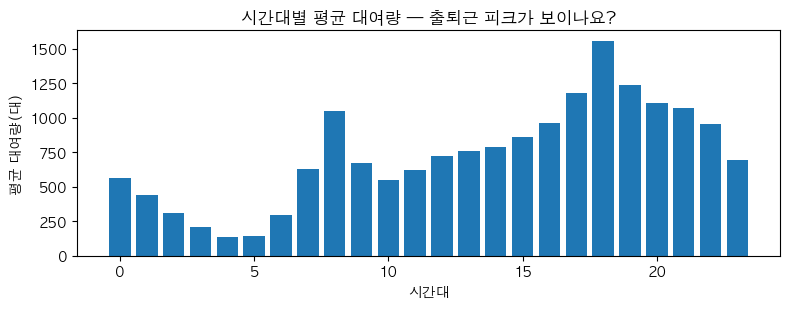

In [3]:
# [Step 1.5] 데이터 확인(EDA) — 학습 전에 데이터부터 봅니다 (제공)
NUM = ["시간","기온","습도","풍속","가시거리","이슬점","일사량","강우량","적설량"]   # 기본 과제가 쓰는 9개 특성
print(df[NUM + ["대여량"]].describe().round(1).to_string())
# ↑ 특성마다 스케일이 제각각입니다(습도 ~58 vs 가시거리 ~1400) — [Step 4] 표준화가 필요한 이유

# 여러분의 '자전거 직감'이 데이터에 있는지 확인해 봅시다
rain = df["강우량"] > 0
print(f"\n비 안 오는 시간 평균 대여: {df.loc[~rain, '대여량'].mean():,.0f}대")
print(f"비 오는 시간 평균 대여:   {df.loc[rain, '대여량'].mean():,.0f}대  ← 직감대로인가요?")

plt.figure(figsize=(8, 3.2))
plt.bar(range(24), df.groupby("시간")["대여량"].mean())
plt.xlabel("시간대"); plt.ylabel("평균 대여량(대)")
plt.title("시간대별 평균 대여량 — 출퇴근 피크가 보이나요?")
plt.tight_layout(); plt.show()

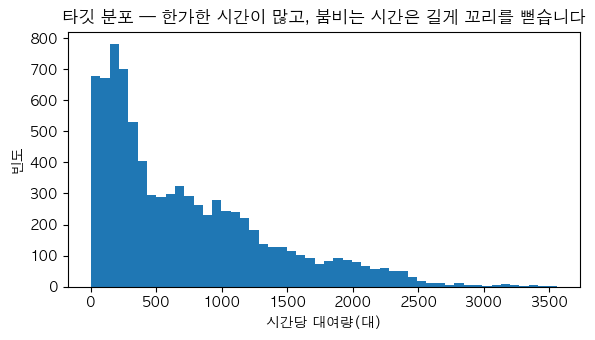

평균 729대 · 최대 3,556대


In [5]:
# [Step 2] 타깃 분포 확인 (제공) — 무엇을 맞히는 문제인지 눈으로
plt.figure(figsize=(6, 3.5))
plt.hist(df["대여량"], bins=50)
plt.xlabel("시간당 대여량(대)"); plt.ylabel("빈도")
plt.title("타깃 분포 — 한가한 시간이 많고, 붐비는 시간은 길게 꼬리를 뻗습니다")
plt.tight_layout(); plt.show()
print(f"평균 {df['대여량'].mean():,.0f}대 · 최대 {df['대여량'].max():,}대")

In [4]:
# [Step 3] 날짜순 train/validation/test 분할 — 미래 예측을 흉내 냅니다.
X_raw = df[NUM].to_numpy("float32")
y = df["대여량"].to_numpy("float32")

n_train = int(len(X_raw) * 0.70)
n_val_end = int(len(X_raw) * 0.85)
X_train_raw, X_val_raw, X_test_raw = X_raw[:n_train], X_raw[n_train:n_val_end], X_raw[n_val_end:]
y_train, y_val, y_test = y[:n_train], y[n_train:n_val_end], y[n_val_end:]

print(f"train {X_train_raw.shape}: {df['날짜_dt'].iloc[0].date()} ~ {df['날짜_dt'].iloc[n_train-1].date()}")
print(f"validation {X_val_raw.shape}: {df['날짜_dt'].iloc[n_train].date()} ~ {df['날짜_dt'].iloc[n_val_end-1].date()}")
print(f"test {X_test_raw.shape}: {df['날짜_dt'].iloc[n_val_end].date()} ~ {df['날짜_dt'].iloc[-1].date()} (봉인)")


train (5925, 9): 2017-12-01 ~ 2018-08-06
validation (1270, 9): 2018-08-06 ~ 2018-10-03
test (1270, 9): 2018-10-03 ~ 2018-11-30 (봉인)


In [6]:
# [Step 4] train 통계로 세 조각을 표준화합니다.

# 반드시 train 데이터로만 평균과 표준편차 계산
mean = X_train_raw.mean(axis=0)
std = X_train_raw.std(axis=0)

# 표준편차가 0인 특성의 0 나누기 방지
std[std == 0] = 1

# Validation과 test에도 train의 mean/std 사용
X_train = (
    (X_train_raw - mean) / std
).astype(np.float32)

X_val = (
    (X_val_raw - mean) / std
).astype(np.float32)

X_test = (
    (X_test_raw - mean) / std
).astype(np.float32)

assert abs(float(X_train.std()) - 1) < 0.1, \
    "표준화가 안 됐습니다"

assert np.isfinite(X_train).all() \
    and np.isfinite(X_val).all(), \
    "nan/inf를 확인하세요"

print(
    "✅ 표준화 통과 · train 평균:",
    X_train.mean().round(4),
    "표준편차:",
    X_train.std().round(4),
)

✅ 표준화 통과 · train 평균: 0.0 표준편차: 1.0


In [7]:
# [Step 5] 회귀 모델과 손실 함수
import torch
import torch.nn as nn

torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),

    nn.Linear(64, 64),
    nn.ReLU(),

    # 시간당 대여량 값 하나 출력
    nn.Linear(64, 1),
).to(DEVICE)

# 실제 대여량과 예측 대여량의 차이를 학습
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

print(model)

Sequential(
  (0): Linear(in_features=9, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)


In [8]:
# [Step 6] 회귀 모델 훈련

xt = torch.tensor(
    X_train,
    dtype=torch.float32,
    device=DEVICE,
)

yt = torch.tensor(
    y_train,
    dtype=torch.float32,
    device=DEVICE,
).reshape(-1, 1)

EPOCHS = 30
BATCH_SIZE = 256
train_losses = []

for epoch in range(EPOCHS):
    model.train()

    perm = torch.randperm(
        len(xt),
        device=DEVICE,
    )

    total_loss = 0.0
    total_count = 0

    for i in range(0, len(xt), BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]

        xb = xt[idx]
        yb = yt[idx]

        # ① 이전 gradient 초기화
        optimizer.zero_grad()

        # ② 순전파
        predictions = model(xb)

        # ③ 손실 계산
        loss = loss_fn(predictions, yb)

        # ④ 역전파
        loss.backward()

        # ⑤ 모델 파라미터 업데이트
        optimizer.step()

        total_loss += loss.item() * len(xb)
        total_count += len(xb)

    epoch_loss = total_loss / total_count
    train_losses.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"epoch {epoch + 1}/{EPOCHS} "
            f"평균 train loss: {epoch_loss:,.1f}"
        )

epoch 10/30 평균 train loss: 401,519.4
epoch 20/30 평균 train loss: 175,045.1
epoch 30/30 평균 train loss: 164,894.7


validation MAE: 401.1대 — validation 시점에서 평균 약 401대 벗어납니다
시간대 평균 기준선 validation MAE: 452.3대


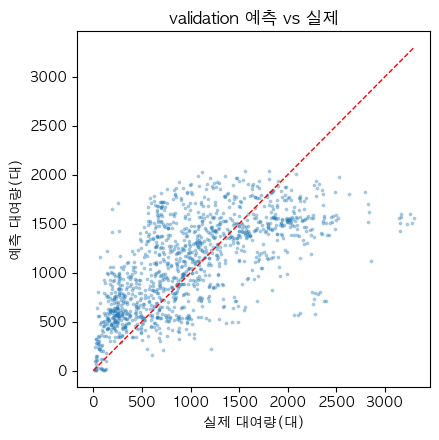

In [9]:
# [Step 7] validation 평가 — test는 아직 열지 않습니다.
model.eval()
with torch.no_grad():
    val_pred = model(torch.tensor(X_val, device=DEVICE)).cpu().numpy().ravel()

val_mae = float(np.abs(val_pred - y_val).mean())
print(f"validation MAE: {val_mae:,.1f}대 — validation 시점에서 평균 약 {val_mae:,.0f}대 벗어납니다")
# TODO: 이 오차가 실제 자전거 재배치 의사결정에 충분한지 한 문장으로 해석하세요.

# 단순 기준선: train의 시간대별 평균만으로 validation 예측
train_hours = df["시간"].iloc[:n_train].to_numpy()
val_hours = df["시간"].iloc[n_train:n_val_end].to_numpy()
hour_mean = {h: y_train[train_hours == h].mean() for h in range(24)}
naive_val_pred = np.array([hour_mean[h] for h in val_hours], dtype="float32")
naive_val_mae = float(np.abs(naive_val_pred - y_val).mean())
print(f"시간대 평균 기준선 validation MAE: {naive_val_mae:,.1f}대")

plt.figure(figsize=(4.5, 4.5))
plt.scatter(y_val, val_pred, s=3, alpha=0.3)
lim = max(y_val.max(), val_pred.max())
plt.plot([0, lim], [0, lim], "r--", lw=1)
plt.xlabel("실제 대여량(대)"); plt.ylabel("예측 대여량(대)")
plt.title("validation 예측 vs 실제")
plt.tight_layout(); plt.show()


### [Step 8] 손잡이 탐색 — validation으로 최소 3개

| 손잡이 | 기본값 | 예상 변화 |
|---|---|---|
| `hidden` | 64 | 용량과 과소·과대적합 균형 |
| `epochs` | 30 | 더 오래 학습하되 validation으로 판단 |
| `lr` | 1e-3 | 수렴 속도와 안정성 변화 |
| `batch` | 256 | gradient 표본 크기 변화 |

| 실험 | 바꾼 것 | 가설 | validation MAE | 다음 수 |
|---|---|---|---|---|
| 기준 | 전부 기본값 | — | (내 결과) | |
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |

한 번에 하나만 바꾸고 실패도 기록합니다. 이 단계의 함수는 test를 받지 않습니다.


In [12]:
# [Step 8 도구] run_reg — train으로 학습하고 validation MAE를 반환합니다.
import time

def run_reg(hidden=64, epochs=30, lr=1e-3, batch=256, seed=0):
    torch.manual_seed(seed)
    m = nn.Sequential(nn.Linear(X_train.shape[1], hidden), nn.ReLU(),
                      nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1)).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    xt_ = torch.tensor(X_train, device=DEVICE)
    yt_ = torch.tensor(y_train, device=DEVICE).reshape(-1, 1)
    t0, losses = time.time(), []
    for epoch in range(epochs):
        m.train(); perm = torch.randperm(len(xt_)); ep_loss, n_b = 0.0, 0
        for i in range(0, len(xt_), batch):
            b = perm[i:i+batch]
            opt.zero_grad(); loss = loss_fn(m(xt_[b]), yt_[b]); loss.backward(); opt.step()
            ep_loss += loss.item(); n_b += 1
        losses.append(ep_loss / n_b)
    m.eval()
    with torch.no_grad():
        p = m(torch.tensor(X_val, device=DEVICE)).cpu().numpy().ravel()
    val_mae_ = float(np.abs(p - y_val).mean())
    n = sum(pm.numel() for pm in m.parameters())
    print(f"val MAE {val_mae_:,.1f}대 · 파라미터 {n:,} · {time.time()-t0:.1f}초"
          f"  ← hidden {hidden} · epochs {epochs} · lr {lr} · batch {batch}")
    return m, val_mae_, losses

# TODO ④ — validation 실험 최소 3개. 예시:
# candidate1, val1, losses1 = run_reg(hidden=16)
# candidate2, val2, losses2 = run_reg(epochs=60)
# candidate3, val3, losses3 = run_reg(hidden=128)
# 추가 예: best_reg, best_val_mae, best_losses = run_reg(epochs=100)
# 🎯 통과선: validation 410대 이하 — 어떤 손잡이가 가장 효과적인지 직접 확인해 보세요


## ✅ 과제 완료 기준

| 기준 | 통과선 |
|---|---|
| TODO ①~④ | 자리표시(`...`) 잔존 0 |
| 날짜순 분할 | train 70% / validation 15% / test 15% |
| validation MAE | **410대 이하** |
| 손잡이 탐색 | validation 실험 3개 이상 + 기록 |
| 최종 test | 설정 확정 뒤 1회만 평가 — 목표 **330대 이하** |
| Streamlit | URL 접속 + 사이드바 val/test MAE |

목표: validation **410 이하**(통과) → **390 이하** → **375 이하**(도전), 최종 test **330대 이하**. 시간 분할은 무작위 분할보다 어렵지만 미래 예측 질문에 더 정직합니다.


val MAE 393.3대 · 파라미터 17,921 · 1.5초  ← hidden 128 · epochs 30 · lr 0.001 · batch 256
val MAE 359.0대 · 파라미터 17,921 · 3.5초  ← hidden 128 · epochs 60 · lr 0.001 · batch 256
val MAE 307.4대 · 파라미터 17,921 · 4.0초  ← hidden 128 · epochs 100 · lr 0.001 · batch 256
val MAE 285.5대 · 파라미터 68,609 · 5.7초  ← hidden 256 · epochs 100 · lr 0.001 · batch 256
선택된 모델: 256 / 100ep · validation MAE 285.5대


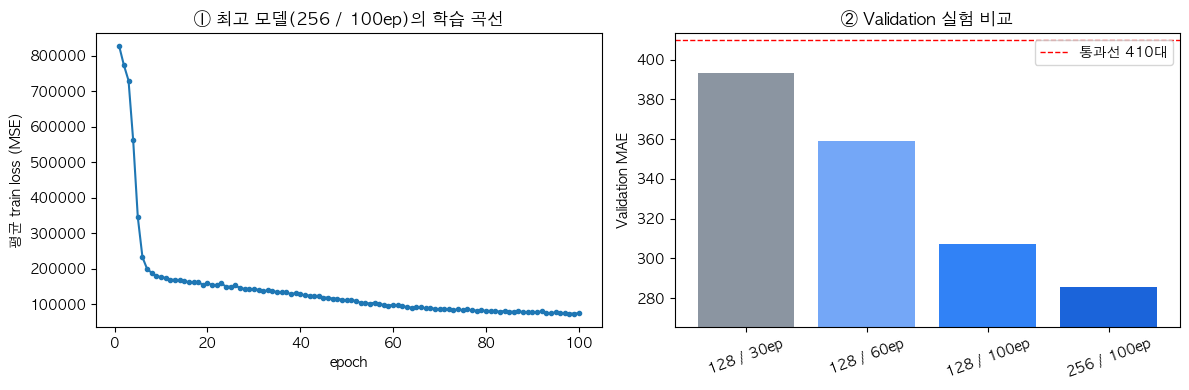

In [18]:
# [제출물] validation 실험 실행 + 그래프 2종

import numpy as np
import matplotlib.pyplot as plt

# Validation 실험 실행
candidate1, val1, losses1 = run_reg(
    hidden=128,
    epochs=30,
)

candidate2, val2, losses2 = run_reg(
    hidden=128,
    epochs=60,
)

candidate3, val3, losses3 = run_reg(
    hidden=128,
    epochs=100,
)

candidate4, val4, losses4 = run_reg(
    hidden=256,
    epochs=100,
)

# 실험 결과 정리
experiments = [
    {
        "name": "128 / 30ep",
        "model": candidate1,
        "mae": val1,
        "losses": losses1,
        "config": {
            "hidden": 128,
            "epochs": 30,
            "lr": 1e-3,
            "batch": 256,
        },
    },
    {
        "name": "128 / 60ep",
        "model": candidate2,
        "mae": val2,
        "losses": losses2,
        "config": {
            "hidden": 128,
            "epochs": 60,
            "lr": 1e-3,
            "batch": 256,
        },
    },
    {
        "name": "128 / 100ep",
        "model": candidate3,
        "mae": val3,
        "losses": losses3,
        "config": {
            "hidden": 128,
            "epochs": 100,
            "lr": 1e-3,
            "batch": 256,
        },
    },
    {
        "name": "256 / 100ep",
        "model": candidate4,
        "mae": val4,
        "losses": losses4,
        "config": {
            "hidden": 256,
            "epochs": 100,
            "lr": 1e-3,
            "batch": 256,
        },
    },
]

# Validation MAE가 가장 낮은 실험 선택
best_experiment = min(
    experiments,
    key=lambda item: item["mae"],
)

BEST_NAME = best_experiment["name"]
BEST_VAL_MAE = best_experiment["mae"]
BEST_LOSSES = best_experiment["losses"]
BEST_CONFIG = best_experiment["config"]
best_reg = best_experiment["model"]

print(
    f"선택된 모델: {BEST_NAME} · "
    f"validation MAE {BEST_VAL_MAE:,.1f}대"
)

# 그래프용 데이터
best_losses = BEST_LOSSES

my_results = {
    experiment["name"]: experiment["mae"]
    for experiment in experiments
}

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

# ① 최고 모델의 학습 곡선
ax1.plot(
    range(1, len(best_losses) + 1),
    best_losses,
    marker="o",
    markersize=3,
)

ax1.set_xlabel("epoch")
ax1.set_ylabel("평균 train loss (MSE)")
ax1.set_title(
    f"① 최고 모델({BEST_NAME})의 학습 곡선"
)

# ② Validation 실험 비교
names = list(my_results.keys())
maes = list(my_results.values())

ax2.bar(
    names,
    maes,
    color=[
        "#8b95a1",
        "#74a7f7",
        "#3182f6",
        "#1b64da",
    ],
)

ax2.axhline(
    410,
    linestyle="--",
    color="red",
    linewidth=1,
    label="통과선 410대",
)

ax2.set_ylim(
    max(0, min(maes) - 20),
    max(maes) + 20,
)

ax2.tick_params(axis="x", rotation=20)
ax2.set_ylabel("Validation MAE")
ax2.set_title("② Validation 실험 비교")
ax2.legend()

plt.tight_layout()
plt.show()

## 2차 과제 — 회귀 Streamlit 앱의 핵심 연결 완성

슬라이더와 결과 패널은 제공되지만 `app_bike.py`는 완성 답안이 아닙니다. 노트북에서 저장한 체크포인트 계약을 읽고 네 핵심 구간을 직접 작성합니다.

```text
과제_Streamlit_앱_회귀/
├─ app_bike.py         ← TODO 1~4 직접 완성
├─ requirements.txt
├─ 배포_가이드.md
└─ bike_reg.pt         ← 다음 셀이 생성
```

직접 완성할 네 가지:

1. `model_config`와 같은 회귀 신경망 구조
2. `state_dict` 복원 후 `eval()`
3. `feature_names` 순서 복원 + 저장된 train `mean/std` 표준화
4. 배치 차원을 추가해 `inference_mode`에서 값 하나 예측

```bash
cd 과제_Streamlit_앱_회귀
python3.11 -m pip install -r requirements.txt
python3.11 -m streamlit run app_bike.py
```

화면에 표시되는 TODO 번호를 따라 완성하고, 슬라이더 하나만 바꿨을 때 예측이 어떻게 달라지는지 설명하세요.

In [19]:
# [2차 1/2] validation 최고 모델 확정 → test 1회 → 안전한 딕셔너리 체크포인트 저장
# 아래 설정을 내 최고 실험과 맞추세요. 기본 모델을 고르면 그대로 둡니다.
best_reg = model
BEST_VAL_MAE = val_mae
BEST_CONFIG = {"hidden": 64, "epochs": EPOCHS, "lr": 1e-3, "batch": 256}

best_reg.eval()
with torch.no_grad():
    test_pred = best_reg(torch.tensor(X_test, device=DEVICE)).cpu().numpy().ravel()
FINAL_TEST_MAE = float(np.abs(test_pred - y_test).mean())

from pathlib import Path
app_dir = Path("과제_Streamlit_앱_회귀")
app_dir.mkdir(exist_ok=True)
checkpoint = {
    "state_dict": best_reg.state_dict(),
    "mean": torch.tensor(mean, dtype=torch.float32),
    "std": torch.tensor(std, dtype=torch.float32),
    "feature_names": NUM,
    "model_config": {"input_dim": X_train.shape[1], "hidden": BEST_CONFIG["hidden"]},
    "training_config": {k: BEST_CONFIG[k] for k in ["epochs", "lr", "batch"]},
    "metrics": {"val_mae": BEST_VAL_MAE, "test_mae": FINAL_TEST_MAE},
}
torch.save(checkpoint, app_dir / "bike_reg.pt")
print(f"최종 확정: validation {BEST_VAL_MAE:,.1f}대 · test {FINAL_TEST_MAE:,.1f}대 (test는 이 1회만)")
print(f"저장 완료: {app_dir / 'bike_reg.pt'}")


최종 확정: validation 401.1대 · test 343.3대 (test는 이 1회만)
저장 완료: 과제_Streamlit_앱_회귀/bike_reg.pt


In [20]:
# [2차 2/2] 배포 폴더 사전 점검 — app_bike.py는 배포 폴더에 이미 제공됩니다.
from pathlib import Path
app_dir = Path("과제_Streamlit_앱_회귀")
required = [app_dir / "app_bike.py", app_dir / "requirements.txt", app_dir / "bike_reg.pt"]
for path in required:
    print("✅" if path.exists() else "❌", path)
assert all(path.exists() for path in required), "위 ❌ 파일을 준비한 뒤 배포하세요"
print("로컬 실행: python3.11 -m streamlit run 과제_Streamlit_앱_회귀/app_bike.py")


✅ 과제_Streamlit_앱_회귀/app_bike.py
✅ 과제_Streamlit_앱_회귀/requirements.txt
✅ 과제_Streamlit_앱_회귀/bike_reg.pt
로컬 실행: python3.11 -m streamlit run 과제_Streamlit_앱_회귀/app_bike.py


## 3차 과제 (필수) — 두 모델을 통합 showcase로 설명하기

이제 분류와 회귀를 별도 `.py` 두 개로 끝내지 않고 하나의 포트폴리오로 연결합니다.

1. `showcase/profile.py`에서 이름을 수정합니다.
2. 분류 모델의 실사용 한계, 회귀 MAE의 의미, 다음 실험을 각각 한 문장으로 작성합니다.
3. Home에서 두 프로젝트 카드가 보이고 두 페이지로 이동되는지 확인합니다.

```bash
cd 미니프로젝트
python3.11 -m streamlit run showcase/Home.py
```

Streamlit Community Cloud의 Main file path는 `showcase/Home.py`입니다. 최종 제출은 두 모델을 함께 보여주는 showcase URL 하나를 권장합니다. 자세한 배포 파일 목록은 `showcase/README.md`를 확인하세요.

## 🏆 리더보드 — 최종 test는 한 번만

| 항목 | 규칙 |
|---|---|
| 모델 선택 | validation MAE가 가장 낮은 설정 |
| 제출 점수 | 선택을 끝낸 뒤 1회 계산한 test MAE |
| 재학습 | test를 보고 바꾸면 변경 사유를 공개하고 별도 트랙으로 기록 |

목표: 최종 test MAE **330대 이하**. 날짜 구간의 계절·수요 수준이 달라 validation과 test 난도가 같지 않을 수 있습니다.

| 이름 | 앱 URL | validation MAE | test MAE | 내 최고의 한 수 | 해석 |
|---|---|---|---|---|---|
| (예) 홍길동 | https://...streamlit.app | 3xx.x | 3xx.x | epochs 늘리기 | 미래 구간에서 평균 약 3xx대 오차 |


> 🏅 **[도전/심화 1]** — 아래는 **선택** 과제입니다. 손잡이 조정과는 차원이 다른 개선을 경험해 보세요.

In [ ]:
# 🏅 [도전] 시간 특성 추가 — 추가했다고 자동으로 좋아지는지 validation으로 검증합니다.
# 날짜순 분할에서는 train에 없던 계절이 validation/test에 나타날 수 있습니다.
# 따라서 전체 자료를 무작위로 섞었을 때의 개선 수치를 그대로 기대하면 안 됩니다.

day_of_week = df["날짜_dt"].dt.dayofweek.to_numpy("float32")
holiday = (df["휴일"] == "Holiday").to_numpy("float32")
X_challenge_raw = np.column_stack([
    df[NUM].to_numpy("float32"),
    np.sin(2 * np.pi * day_of_week / 7),
    np.cos(2 * np.pi * day_of_week / 7),
    holiday,
]).astype("float32")

# ① [Step 3]과 같은 경계로 날짜순 분할
# ② train 통계로만 표준화
# ③ run_reg와 같은 구조로 validation MAE 비교
# ④ 좋아지지 않았다면 “추가 정보 ≠ 유용한 정보”인 이유를 데이터 기간과 함께 설명
# ⚠️ 필수 배포 앱은 기본 9개 특성 모델을 사용합니다. 도전 모델은 노트북 제출 범위입니다.


## 3️⃣ Debug — 흔한 오류 (증상과 힌트만 — 원인·수정은 정답지에)

| # | 증상 | 힌트 |
|---|---|---|
| 1 | loss가 수십만~nan으로 폭주 | [Step 4]를 건너뛰면 어떤 특성이 학습을 지배할까요? |
| 2 | 경고 없이 돌아가는데 MAE가 이상하게 큼 — `UserWarning: ... target size ... input size` | 모델 출력 (N,1)과 정답 (N,)이 만나면 broadcasting이 무슨 일을 할까요? |
| 3 | `RuntimeError` — CrossEntropyLoss에 float 정답 | 클래스 맞히기와 값 맞히기의 손실은 다릅니다 (계약 ④) |
| 4 | test MAE가 훈련보다 좋게 나옴 (수상할 정도로) | 표준화할 때 어느 데이터의 mean/std를 썼나요? |
| 5 | [도전 1]에서 `nan` 발생 | 어떤 열의 표준편차가 0이면 0으로 나누게 됩니다 — 도전 1의 ⚠️ 참조 |

## 2️⃣ Review — 내 과제 코드를 AI에게 리뷰받기

제출 전에 아래 셀로 내 코드(특히 TODO로 채운 부분)를 리뷰받아 보세요.

In [ ]:
# ── 2️⃣ Review (코드형) — 로컬/클라우드 LLM에게 내 코드·판단을 리뷰받기 ──
# [사전조건] 로컬: LM Studio(00-1)/Ollama(00-2) 서버 실행  |  클라우드: OPENROUTER/OPENAI 키 설정
# openai 패키지가 없으면 아래 주석을 풀어 한 번만 실행하세요 (이미 있으면 건너뛰기)
# !pip install openai
import os
from openai import OpenAI

PROVIDER = "lmstudio"   # "lmstudio" | "ollama" | "openrouter" | "openai"  ← 한 줄만 바꾸면 전환
PROVIDERS = {
    "lmstudio":   {"base_url": "http://localhost:1234/v1",  "model": "local-model",          "api_key": "lm-studio"},
    "ollama":     {"base_url": "http://localhost:11434/v1", "model": "qwen2.5-coder:latest", "api_key": "ollama"},
    "openrouter": {"base_url": "https://openrouter.ai/api/v1", "model": "google/gemma-4-26b-a4b-it:free", "api_key": os.getenv("OPENROUTER_API_KEY", "")},
    "openai":     {"base_url": None, "model": "gpt-4o-mini", "api_key": os.getenv("OPENAI_API_KEY", "")},
}

# 이 과제의 리뷰 프롬프트
REVIEW_PROMPT = """딥러닝 입문 과제(서울 자전거 대여 수요 회귀)를 제출하기 전이야. 내가 작성한 아래 코드를 리뷰해줘 —
① 날짜·시간 정렬 뒤 연속된 train/validation/test로 나눴는지 ② 표준화가 train 통계로만 계산됐는지
③ 출력층 1·MSELoss·정답 shape (N,1)이 맞는지 ④ 손잡이 탐색은 validation만 사용했는지 ⑤ test는 설정 확정 뒤 한 번만 평가했는지.
잘한 점, 고칠 점, 근거를 나눠서 답해줘.

=== 내 코드 ===
(여기에 TODO로 채운 셀들을 붙여넣으세요)
==================="""

cfg = PROVIDERS[PROVIDER]
client = OpenAI(base_url=cfg["base_url"], api_key=cfg["api_key"] or "none")
try:
    r = client.chat.completions.create(
        model=cfg["model"], temperature=0.7, max_tokens=2000,
        messages=[
            {"role": "system", "content": "당신은 파이썬·딥러닝을 가르치는 멘토입니다. 정답을 바로 주지 말고 근거와 함께 리뷰하세요."},
            {"role": "user", "content": REVIEW_PROMPT},
        ],
    )
    ans = (r.choices[0].message.content or "").strip()
    print(ans if ans else "⚠️ 빈 답변 — 추론 모델이 max_tokens를 소진했을 수 있습니다(max_tokens↑ 또는 비추론 모델).")
except Exception as e:
    print(f"⚠️ LLM 연결 실패: {e}\n→ 로컬 서버(LM Studio/Ollama) 실행 여부와 PROVIDER 설정을 확인하세요.")

---
## ✅ 제출 체크리스트

- [ ] 날짜순 train/validation/test와 train 통계 표준화 확인
- [ ] validation 실험 3개 이상 + 학습 곡선·실험 비교 그래프
- [ ] 설정 확정 뒤 test 1회 평가 + MAE 해석 문장
- [ ] 회귀 앱 TODO 1~4 완성 + 슬라이더·예측·사이드바 확인
- [ ] `showcase/profile.py` 작성 + Home·분류·회귀 페이지가 열리는 통합 URL 제출
- [ ] 리더보드 1행 작성

## 📚 [세션 요약]

> 1. 분류와 회귀의 직접 차이는 출력층과 손실이며 훈련 5단계는 같습니다.
> 2. 미래 예측 문제는 시간 순서를 지켜 나눕니다.
> 3. train 통계로 세 조각을 변환하고, validation으로 선택하고, test는 마지막에 한 번만 봅니다.
> 4. 특성을 추가해도 미래 validation에서 좋아진다는 보장은 없습니다.
